### - This project builds an Impact Score to evaluate IPL batters beyond traditional metrics like total runs.

# Introduction

- Why only Runs or average or strike rate is not enough to find the impact of a player in the team ?

- Why impact matters ?

### Problem Statement:

- Traditional cricket metrics like runs, average, and strike rate provide limited insights into a player’s true performance. This project aims to identify the most impactful IPL batters by combining multiple factors such as scoring efficiency, consistency, and match contribution into a unified impact score. This approach enables a more holistic evaluation of player influence in T20 cricket.

### Data Understanding

- First of all let's take a glimpse towards our data that what we have
- This IPL dataset i am using is taken from open source Kaggle plateform

In [1]:
# Let's import necessary libraries

from io import StringIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# dataset accessing
# I have named my whole dataset as ipl
ipl = pd.read_csv('IPL.csv' , low_memory=False)

- now lets look as all the columns 

In [3]:
ipl.head()  # so much columns but only few are for our means

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


#### The columns require for our project are :-
- batter → name of the batsman
- runs_batter → runs scored by the batsmans
- runs_total → total runs including extras
- valid_ball → indicates legal deliveries
- striker_out → whether batter got out
- match_id → unique match identifier
- batting_team → team batting



## Feature Engineering

- Now let's start understanding each metrics or features

- Since the dataset is at ball-by-ball level, it is first aggregated at the batter level to compute total runs, balls faced, dismissals, and matches played.

In [44]:
bat = ipl.groupby('batter').agg(
    total_runs = ('runs_batter' , 'sum'),
    ball_faced = ('valid_ball' , 'sum'),
    matches_played = ('match_id' , 'nunique'),
    dismissals = ('striker_out' , lambda x : ((x == True)).sum())
).reset_index()

# Here i have named my new DataFrame as 'bat' 
# i have aggregate the ipl dataframe grouped by each batsman so that we can analyse features 

- Now, To show what out 'bat' DataFrame contains we will do bat.head() 

In [7]:
bat.head()     # Now as you can see it is not good to see performance of top performers so we will sort out in bat

,batter,total_runs,ball_faced,matches_played,got_out
0,A Ashish Reddy,280,193,23,15
1,A Badoni,963,693,46,35
2,A Chandila,4,7,2,0
3,A Chopra,53,71,6,5
4,A Choudhary,25,20,3,1


In [5]:
bat.sort_values(by='total_runs'  ,ascending=False).head(20)

# Here you can see that i have taken out top 20 batsman based on total runs scored in IPL History

,batter,total_runs,ball_faced,matches_played,dismissals
658,V Kohli,8671,6505,259,217
500,RG Sharma,7048,5317,266,235
535,S Dhawan,6769,5304,221,187
151,DA Warner,6567,4680,184,158
569,SK Raina,5536,4025,200,162
389,MS Dhoni,5439,3935,241,139
297,KL Rahul,5235,3836,135,112
31,AB de Villiers,5181,3400,170,122
51,AM Rahane,5032,4021,183,160
128,CH Gayle,4997,3331,141,125


In [45]:
bat = bat[((bat['ball_faced'] > 300) & (bat['matches_played'] > 30) & (bat['total_runs'] > 500))] 

#### Strike Rate

- Strike rate measures how quickly a batter scores runs and reflects scoring efficiency in T20 cricket.
- What is Strike Rate :- It is (runs scored/total ball played) x 100

In [46]:
# in code form

bat['strike_rate'] = (bat['total_runs'] / bat['ball_faced'])*100

# as i will show you output that 'strike_rate' column will be added to our dataframe

bat.sort_values(by='total_runs' , ascending=False).head(10)     # if sorted by total runs
# bat.sort_values(by='strike_rate' , ascending=False).head(10)     # if sorted by strike rate

,batter,total_runs,ball_faced,matches_played,dismissals,strike_rate
658,V Kohli,8671,6505,259,217,133.297463
500,RG Sharma,7048,5317,266,235,132.555953
535,S Dhawan,6769,5304,221,187,127.620664
151,DA Warner,6567,4680,184,158,140.320513
569,SK Raina,5536,4025,200,162,137.540373
389,MS Dhoni,5439,3935,241,139,138.221093
297,KL Rahul,5235,3836,135,112,136.470282
31,AB de Villiers,5181,3400,170,122,152.382353
51,AM Rahane,5032,4021,183,160,125.142999
128,CH Gayle,4997,3331,141,125,150.015011


#### Average of Batsman

- Batting average indicates consistency by measuring how many runs a player scores before getting dismissed.
- What is Batting Average :- It is (runs scored/total dismissals of that batsman)

In [47]:
# in code form

bat['average'] = bat['total_runs'] / bat['dismissals']

# as i will show you output that 'average' column will be added to our dataframe

bat.sort_values(by='total_runs' , ascending=False).head(10)     # if sorted by total runs
# bat.sort_values(by='strike_rate' , ascending=False).head(10)     # if sorted by strike rate
# bat.sort_values(by='average' , ascending=False).head(10)     # if sorted by average

,batter,total_runs,ball_faced,matches_played,dismissals,strike_rate,average
658,V Kohli,8671,6505,259,217,133.297463,39.958525
500,RG Sharma,7048,5317,266,235,132.555953,29.991489
535,S Dhawan,6769,5304,221,187,127.620664,36.197861
151,DA Warner,6567,4680,184,158,140.320513,41.563291
569,SK Raina,5536,4025,200,162,137.540373,34.172840
389,MS Dhoni,5439,3935,241,139,138.221093,39.129496
297,KL Rahul,5235,3836,135,112,136.470282,46.741071
31,AB de Villiers,5181,3400,170,122,152.382353,42.467213
51,AM Rahane,5032,4021,183,160,125.142999,31.450000
128,CH Gayle,4997,3331,141,125,150.015011,39.976000


#### Runs Per Match

- Runs per match captures a player’s overall contribution across matches, balancing performance over time.
- many people thought that it is same as average but it is not because it also add that matched where he was notout
- What is Runs Per Match :- It is (runs scored/total matches played by that batsman)

In [48]:
# in code form

bat['runs_per_match'] = bat['total_runs'] / bat['matches_played']

# as in the output 'runs_per_match' column will be added to our dataframe

bat.sort_values(by='total_runs' , ascending=False).head(10)     # if sorted by total runs
# bat.sort_values(by='strike_rate' , ascending=False).head(10)     # if sorted by strike rate
# bat.sort_values(by='average' , ascending=False).head(10)     # if sorted by average
# bat.sort_values(by='runs_per_match' , ascending=False).head(10)     # if sorted by runs_per_match

,batter,total_runs,ball_faced,matches_played,dismissals,strike_rate,average,runs_per_match
658,V Kohli,8671,6505,259,217,133.297463,39.958525,33.478764
500,RG Sharma,7048,5317,266,235,132.555953,29.991489,26.496241
535,S Dhawan,6769,5304,221,187,127.620664,36.197861,30.628959
151,DA Warner,6567,4680,184,158,140.320513,41.563291,35.690217
569,SK Raina,5536,4025,200,162,137.540373,34.172840,27.680000
389,MS Dhoni,5439,3935,241,139,138.221093,39.129496,22.568465
297,KL Rahul,5235,3836,135,112,136.470282,46.741071,38.777778
31,AB de Villiers,5181,3400,170,122,152.382353,42.467213,30.476471
51,AM Rahane,5032,4021,183,160,125.142999,31.450000,27.497268
128,CH Gayle,4997,3331,141,125,150.015011,39.976000,35.439716


#### Contribution %

- now for contribution % we will derive the stats in detail but for now we will understand what contribution means
- What is Contribution % :- It is (batter_runs / team_runs) * 100

#### Consistency (CV)

- now for Consistency (CV) also we will derive the stats in detail but for now we will understand what Consistency (CV) means
- What is Consistency (CV) :- It is cv (standard_deviation of runs / mean of runs)

## Exploratory Analysis

- now let us show dataframe and plotting also to visualize what we have got using feature engineering

### plot top run getters using bar plotting 

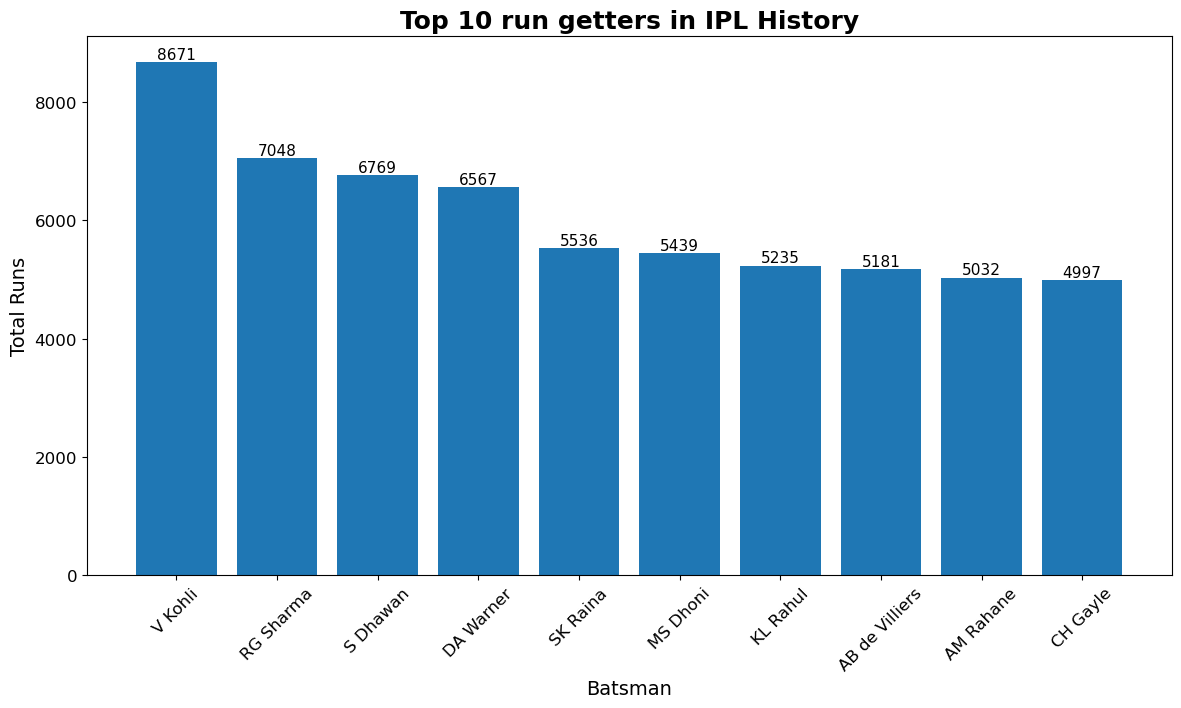

In [46]:
# this was our code for top 10 run getters
top_20 = bat.sort_values(by='total_runs' , ascending=False).head(10)

# Now for plotting Bar Graph we will use MatPlotLib

plt.figure(figsize=(14,7))                                 # It will define the figure size of out graph
plt.bar(top_20['batter'] ,top_20['total_runs'] )                 # It will plot graph between batsman v/s Total Runs
plt.title("Top 10 run getters in IPL History" , fontsize=18 , fontweight='bold')            # It will add Title for our Bar Plot
plt.xlabel("Batsman" , fontsize=14)                        # It will lable our X-axis to 'Batsman'
plt.ylabel("Total Runs",fontsize=14)                       # It will lable our Y-axis to 'Total Runs'
plt.xticks(rotation = 45,fontsize = 12)                    # It will change fontsize of x-axis entries for better visuals and rotate names by 45 degree
plt.yticks(fontsize = 12)                                  # It will change fontsize of y-axis entries for better visuals


for i in range(len(top_20)):
    plt.text(i,
             top_20['total_runs'].iloc[i]+50,               # this peace of code will show the exact runs of batsman above each bar 
             top_20['total_runs'].iloc[i],
             ha='center', fontsize=11)

    
plt.show()

### plot for top 10 batsman with most Strike rate using bar plotting

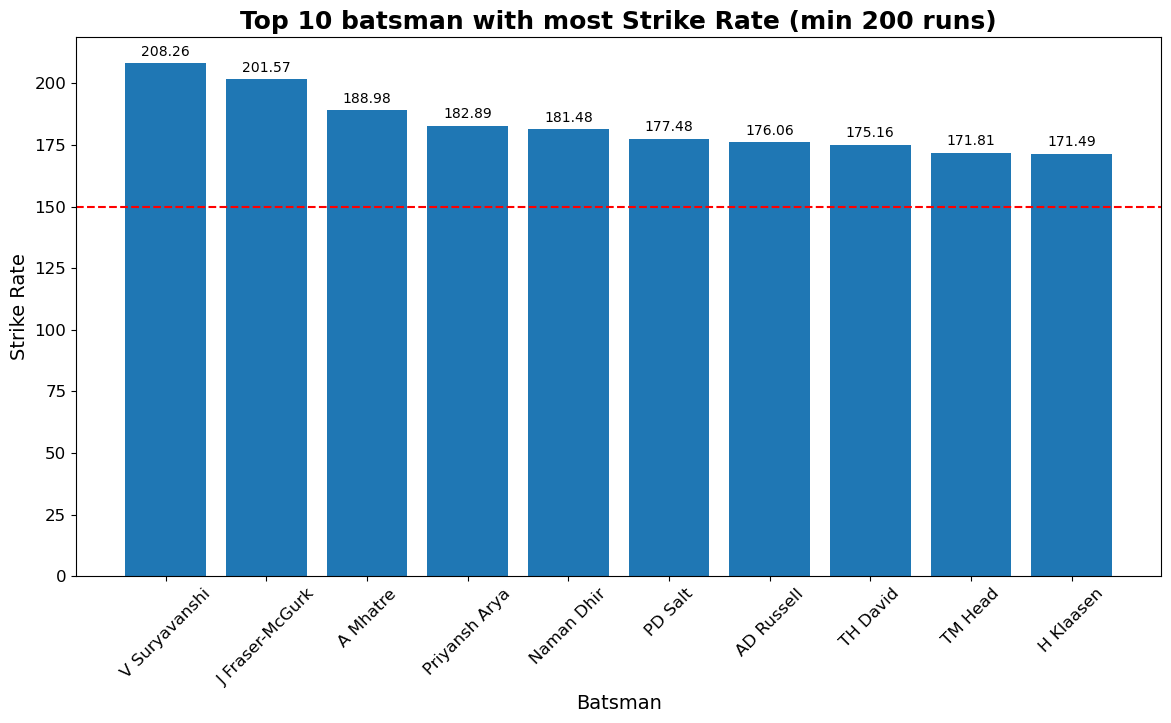

In [51]:
# this was our code for top 10 batsman with most strike rate

top_20 = bat[bat['total_runs'] > 200]     # I have filtered out the noises means that batsman must have scored above some threshold runs (here 200)

top_20 = top_20.sort_values(by='strike_rate' , ascending=False).head(10)

# Similarly for plotting Bar Graph we will use MatPlotLib

plt.figure(figsize=(14,7))                                 # It will define the figure size of out graph
plt.bar(top_20['batter'] ,top_20['strike_rate'] )                 # It will plot graph between batsman v/s Strike rate
plt.title("Top 10 batsman with most Strike Rate (min 200 runs)" , fontsize=18 , fontweight='bold')            # It will add Title for our Bar Plot
plt.xlabel("Batsman" , fontsize=14)                        # It will lable our X-axis to 'Batsman'
plt.ylabel("Strike Rate",fontsize=14)                       # It will lable our Y-axis to 'Strike rate'
plt.xticks(rotation = 45,fontsize = 12)                    # It will change fontsize of x-axis entries for better visuals and rotate names by 45 degree
plt.yticks(fontsize = 12)                                  # It will change fontsize of y-axis entries for better visuals
plt.axhline(y=150, linestyle='--' , c="r")

for i in range(len(top_20)):
    plt.text(top_20['batter'].iloc[i],
             top_20['strike_rate'].iloc[i]+3,               # this peace of code will show the exact strike rate of batsman above each bar 
             round(top_20['strike_rate'].iloc[i], 2),
             ha='center', fontsize=10)

    
plt.show()

### plot for top 10 batsman with best average using bar plotting

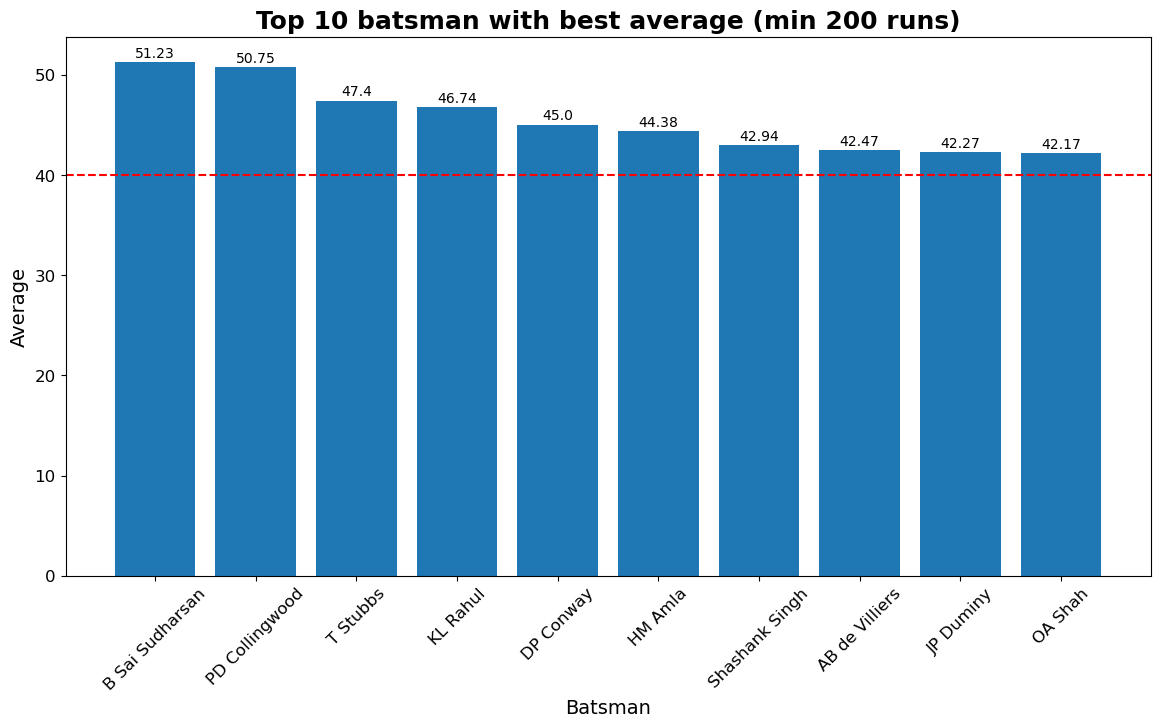

In [56]:
# this was our code for top 10 batsman with best average

top_20 = bat[bat['total_runs'] > 200]     # I have filtered out the noises means that batsman must have scored above some threshold runs (here 200)

top_20 = top_20.sort_values(by='average' , ascending=False).head(10)

# Similarly for plotting Bar Graph we will use MatPlotLib

plt.figure(figsize=(14,7))                                 # It will define the figure size of out graph
plt.bar(top_20['batter'] ,top_20['average'] )                 # It will plot graph between batsman v/s Average
plt.title("Top 10 batsman with best average (min 200 runs)" , fontsize=18 , fontweight='bold')            # It will add Title for our Bar Plot
plt.xlabel("Batsman" , fontsize=14)                        # It will lable our X-axis to 'Batsman'
plt.ylabel("Average",fontsize=14)                       # It will lable our Y-axis to 'Average'
plt.xticks(rotation = 45,fontsize = 12)                    # It will change fontsize of x-axis entries for better visuals and rotate names by 45 degree
plt.yticks(fontsize = 12)                                  # It will change fontsize of y-axis entries for better visuals
plt.axhline(y=40, linestyle='--' , c="r")

for i in range(len(top_20)):
    plt.text(top_20['batter'].iloc[i],
             top_20['average'].iloc[i]+0.5,               # this peace of code will show the exact Average of batsman above each bar 
             round(top_20['average'].iloc[i], 2),
             ha='center', fontsize=10)

    
plt.show()

## Insights from this analysis

- High run scorers are not always high strike rate players
- Some players maintain both consistency and aggression

## Now we will look at Impact of Player

- we will first normalize our data for fair analysis 

In [49]:
# We will bring all our data between 0 to 1 for fair comparison

bat['sr_norm'] = bat['strike_rate'] / bat['strike_rate'].max()
bat['avg_norm'] = bat['average'] / bat['average'].max()
bat['rpm_norm'] = bat['runs_per_match'] / bat['runs_per_match'].max()


- Now think about how to define Impact of a player .
- Yes ! Using all feature component
- now main question is how we measure impact using all these metrics here is a good formula
- impact = (0.4 * sr_norm) + (0.3 * avg_norm) + (0.3 * rpm_norm)

In [50]:
# in code form

# adding threshold for removing noise 


bat['impact'] = (0.4 * bat['sr_norm']) + (0.3 * bat['avg_norm']) + (0.3 * bat['rpm_norm'])

# as i will show you output that 'impact' column will be added to our dataframe

bat.sort_values(by='impact' , ascending=False).head(10)     # if sorted by total runs

,batter,total_runs,ball_faced,matches_played,dismissals,strike_rate,average,runs_per_match,sr_norm,avg_norm,rpm_norm,impact
98,B Sai Sudharsan,1793,1220,40,35,146.967213,51.228571,44.825000,0.828082,1.000000,1.000000,0.931233
213,H Klaasen,1480,863,45,36,171.494786,41.111111,32.888889,0.966282,0.802504,0.733718,0.847379
297,KL Rahul,5235,3836,135,112,136.470282,46.741071,38.777778,0.768938,0.912402,0.865093,0.840824
128,CH Gayle,4997,3331,141,125,150.015011,39.976000,35.439716,0.845255,0.780346,0.790624,0.809393
248,JC Buttler,4121,2749,119,101,149.909058,40.801980,34.630252,0.844658,0.796469,0.772566,0.808574
449,PD Salt,1056,595,34,31,177.478992,34.064516,31.058824,1.000000,0.664952,0.692891,0.807353
643,TM Head,1146,667,37,32,171.814093,35.812500,30.972973,0.968081,0.699073,0.690975,0.804247
151,DA Warner,6567,4680,184,158,140.320513,41.563291,35.690217,0.790632,0.811330,0.796212,0.798515
31,AB de Villiers,5181,3400,170,122,152.382353,42.467213,30.476471,0.858594,0.828975,0.679899,0.796100
495,RD Gaikwad,2502,1811,70,60,138.155715,41.700000,35.742857,0.778434,0.813999,0.797387,0.794789


### plot for top 10 batsman with highest impact using bar plotting

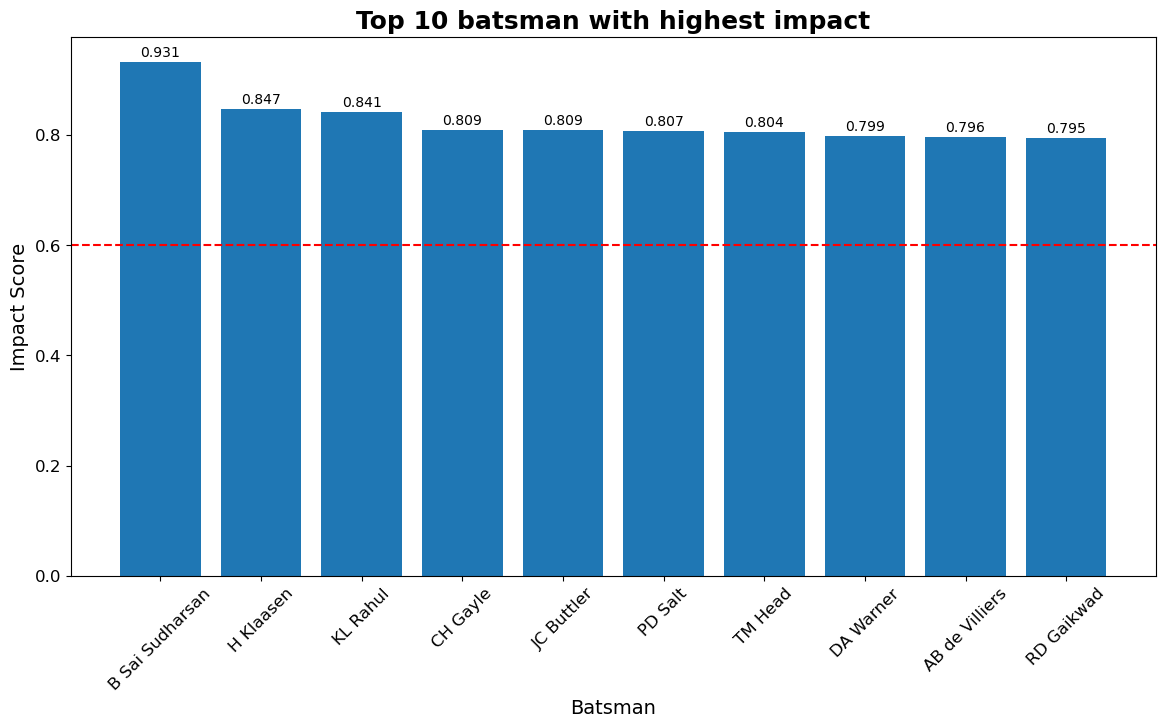

In [23]:
# this was our code for top 10 batsman with best average


bat = bat.sort_values(by='impact' , ascending=False).head(10)

# Similarly for plotting Bar Graph we will use MatPlotLib

plt.figure(figsize=(14,7))                                 # It will define the figure size of out graph
plt.bar(bat['batter'] ,bat['impact'] )                 # It will plot graph between batsman v/s Average
plt.title("Top 10 batsman with highest impact" , fontsize=18 , fontweight='bold')            # It will add Title for our Bar Plot
plt.xlabel("Batsman" , fontsize=14)                        # It will lable our X-axis to 'Batsman'
plt.ylabel("Impact Score",fontsize=14)                       # It will lable our Y-axis to 'Average'
plt.xticks(rotation = 45,fontsize = 12)                    # It will change fontsize of x-axis entries for better visuals and rotate names by 45 degree
plt.yticks(fontsize = 12)                                  # It will change fontsize of y-axis entries for better visuals
plt.axhline(y=0.60, linestyle='--' , c="r")

for i in range(len(bat)):
    plt.text(bat['batter'].iloc[i],
             bat['impact'].iloc[i] +0.01,               # this peace of code will show the exact Average of batsman above each bar 
             round(bat['impact'].iloc[i], 3),
             ha='center', fontsize=10)

    
plt.show()

## Now how to look at consistency of a player

- Consistency is measured using the Coefficient of Variation (CV), which captures variability in a batter’s performance relative to their average. Lower CV indicates more consistent performance.

In [55]:
# in code form 

# we calculate the runs of a batsman in each match
batter_match_runs = ipl.groupby(['batter', 'match_id'])['runs_batter'].sum().reset_index()

# then we will find the mean and varience of runs scored by  that batsman
consistency = batter_match_runs.groupby('batter')['runs_batter'].agg(['mean','var']).reset_index()

# now calculate consistency using formula (standard deviation / mean)
bat['consistency'] = consistency['var'] / consistency['var'].max()
consistency['std'] = consistency['var'] ** 0.5
bat['cv'] = consistency['std'] / consistency['mean']    # in bat dataframe 'cv' column will be added and whoose c is less then he is more consistence

bat.sort_values(by='cv' , ascending=True).head(20)

,batter,total_runs,ball_faced,matches_played,dismissals,strike_rate,average,runs_per_match,sr_norm,avg_norm,rpm_norm,impact,consistency,cv
98,B Sai Sudharsan,1793,1220,40,35,146.967213,51.228571,44.825000,0.828082,1.000000,1.000000,0.931233,0.519289,0.602647
649,Tilak Varma,1499,1032,51,38,145.251938,39.447368,29.392157,0.818418,0.770027,0.655709,0.755088,0.268507,0.660884
475,R Dravid,2174,1878,82,75,115.761448,28.986667,26.512195,0.652254,0.565830,0.591460,0.608089,0.271137,0.736253
48,AK Markram,1440,1062,55,46,135.593220,31.304348,26.181818,0.763996,0.611072,0.584090,0.664147,0.264827,0.736818
268,JP Duminy,2029,1631,75,48,124.402207,42.270833,27.053333,0.700940,0.825142,0.603532,0.708978,0.298067,0.756510
587,SR Tendulkar,2334,1941,78,67,120.247295,34.835821,29.923077,0.677530,0.680008,0.667553,0.675280,0.365283,0.757159
213,H Klaasen,1480,863,45,36,171.494786,41.111111,32.888889,0.966282,0.802504,0.733718,0.847379,0.441659,0.757483
378,ML Hayden,1107,799,32,28,138.548185,39.535714,34.593750,0.780646,0.771751,0.771751,0.775309,0.498121,0.764801
265,JM Sharma,991,628,47,39,157.802548,25.410256,21.085106,0.889134,0.496017,0.470387,0.645575,0.185663,0.766066
507,RK Singh,1099,750,51,36,146.533333,30.527778,21.549020,0.825638,0.595913,0.480737,0.653250,0.194592,0.767385


### plot for top 10 batsman with good consistency using bar plotting

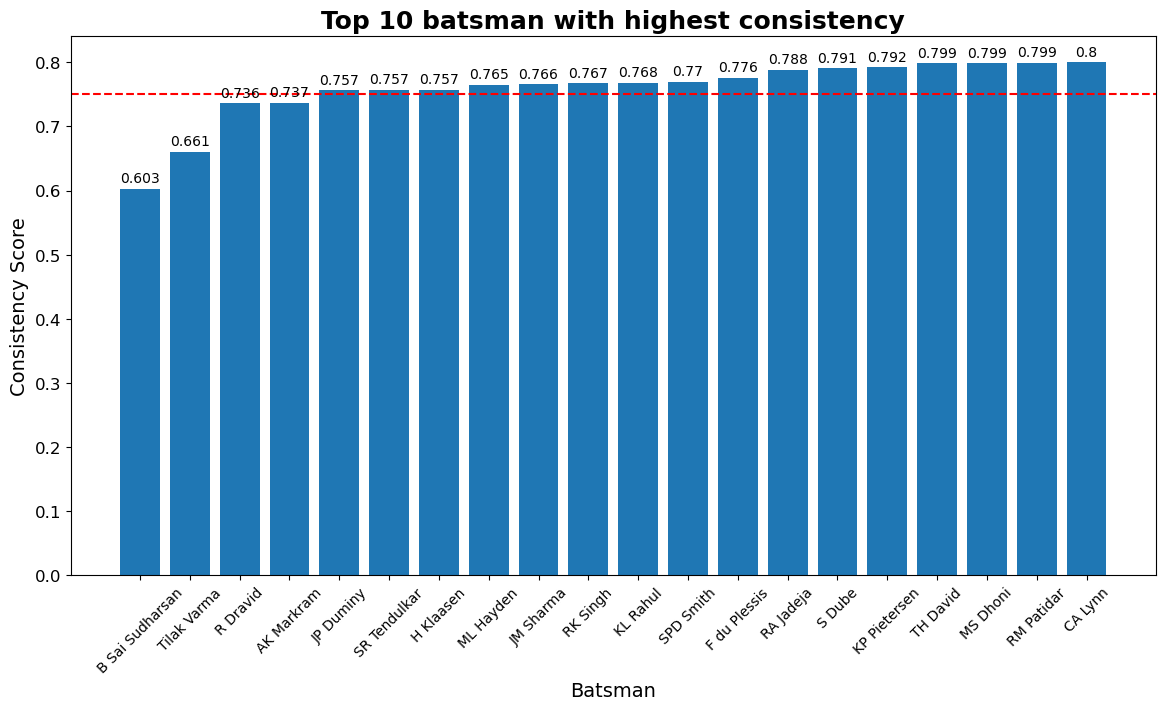

In [59]:
# this was our code for top 10 batsman with best average


top_20 = bat.sort_values(by='cv' , ascending=True).head(20)

# Similarly for plotting Bar Graph we will use MatPlotLib

plt.figure(figsize=(14,7))                                 # It will define the figure size of out graph
plt.bar(top_20['batter'] ,top_20['cv'] )                 # It will plot graph between batsman v/s Average
plt.title("Top 10 batsman with highest consistency" , fontsize=18 , fontweight='bold')            # It will add Title for our Bar Plot
plt.xlabel("Batsman" , fontsize=14)                        # It will lable our X-axis to 'Batsman'
plt.ylabel("Consistency Score",fontsize=14)                       # It will lable our Y-axis to 'Average'
plt.xticks(rotation = 45,fontsize = 10)                    # It will change fontsize of x-axis entries for better visuals and rotate names by 45 degree
plt.yticks(fontsize = 12)                                  # It will change fontsize of y-axis entries for better visuals
plt.axhline(y=0.75, linestyle='--' , c="r")

for i in range(len(top_20)):
    plt.text(top_20['batter'].iloc[i],
             top_20['cv'].iloc[i] +0.01,               # this peace of code will show the exact Average of batsman above each bar 
             round(top_20['cv'].iloc[i], 3),
             ha='center', fontsize=10)

    
plt.show()

## Now we will distribute the category of batsman into different clusters using scatter plot

## Strike Rate v/s Average    comparison

- To better interpret player performance, batters are grouped into distinct categories using thresholds on strike rate and average. This role-based segmentation helps differentiate between aggressive players, anchors, and elite performers. The scatter plot visualizes these categories, while top impact players are annotated to highlight key contributors.

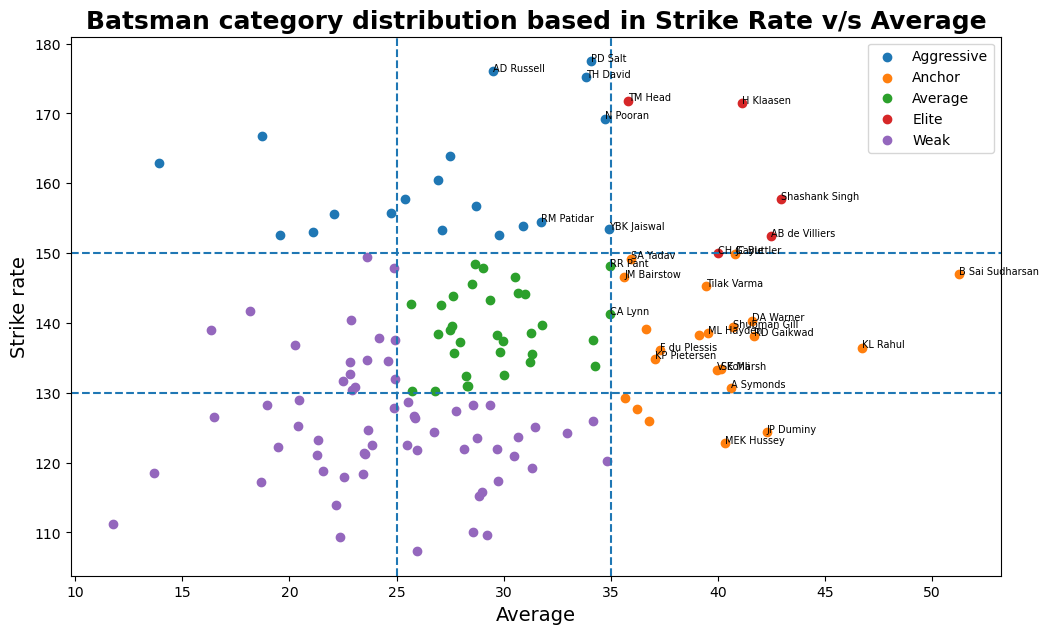

In [63]:
# Categorise the Batsmans into different categories

def category(row):
    if row['strike_rate'] >= 150 and row['average'] >= 35:
        return 'Elite'
    elif row['strike_rate'] >= 150 and row['average'] < 35:
        return 'Aggressive'
    elif row['strike_rate'] < 150 and row['average'] >= 35:
        return 'Anchor'
    elif 130 <= row['strike_rate'] < 150 and 25 <= row['average'] < 35:
        return 'Average'
    else:
        return 'Weak'

bat['category'] = bat.apply(category, axis=1)


plt.figure(figsize=(12,7))

for cat, data in bat.groupby('category'):
    plt.scatter(data['average'], data['strike_rate'], label=cat)

top = bat.sort_values(by='impact', ascending=False).head(30)

for i in range(len(top)):
    plt.text(
        top['average'].iloc[i],
        top['strike_rate'].iloc[i],
        top['batter'].iloc[i],
        fontsize=7
    )

plt.axvline(x=35, linestyle='--')
plt.axhline(y=150, linestyle='--')
plt.axhline(y=130, linestyle='--') 
plt.axvline(x=25, linestyle='--')

plt.legend()
plt.title("Batsman category distribution based in Strike Rate v/s Average" , fontsize=18 , fontweight='bold')            # It will add Title for our Bar Plot
plt.xlabel("Average" , fontsize=14)                        # It will lable our X-axis to 'Batsman'
plt.ylabel("Strike rate",fontsize=14)                       # It will lable our Y-axis to 'Average'


plt.show()

### Insights from this scatter plot

- Players with high strike rate but low average are inconsistent
- Anchors contribute more but have lower impact

## Final Conclusion